<a href="https://colab.research.google.com/github/SHEisSONALI/sonali.github.io/blob/main/Basic_CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sonali

# Installing Kggle for Dataset
Using API token for authenticating with kaggle ID


In [ ]:
!pip install kaggle

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_9887fcb7183178b92091dbbbeaf17ae3"

In [ ]:
import json

token = {"username":"sonaliishekhawat","key":"KGAT_9887fcb7183178b92091dbbbeaf17ae3"}

with open("kaggle.json", "w") as f:
    json.dump(token, f)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured  2,207,152 Usd       3165           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection  

Downloading Dataset onto colab from kaggle

In [ ]:
!kaggle datasets download -d moazawadali/plantvillage-tomato

Dataset URL: https://www.kaggle.com/datasets/moazawadali/plantvillage-tomato
License(s): DbCL-1.0
100% 277M/277M [00:18<00:00, 16.0MB/s]



In [ ]:
!unzip plantvillage-tomato.zip

Streaming output truncated to the last 5000 lines.
  inflating: PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9cfa3f33-36c3-4812-9d23-73898c39d8db___UF.GRC_YLCV_Lab 01362.JPG  
  inflating: PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d00f458-5616-470e-a8ad-9694c01999bb___YLCV_NREC 2276.JPG  
  inflating: PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d032375-b1ce-45ca-a067-e699486d511d___YLCV_GCREC 2220.JPG  
  inflating: PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d101a85-6847-4e83-87bc-63f0794f0032___YLCV_GCREC 2763.JPG  
  inflating: PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d1f2f28-34e4-45ca-9517-e9410054ba5f___YLCV_GCREC 2503.JPG  
  inflating: PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d220ab4-26b6-4367-956b-59b625501152___YLCV_NREC 2600.JPG  
  inflating: PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d341062-6e2c-4e31-8098-75735cea1744___YLCV_NREC 2335.JPG  
  inflating: PlantVill

In [ ]:
import os
data_dir = "PlantVillage"
print(os.listdir(data_dir))

['val', 'test', 'train']


# Basic CNN Model
1. Data Loading (using Directory Structure) And Preprocessing



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = "PlantVillage/train"
val_dir   = "PlantVillage/val"
test_dir  = "PlantVillage/test"

# Data generators
train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)
test_gen  = ImageDataGenerator(rescale=1./255)

# Load data
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # IMPORTANT for evaluation
)

Found 14523 images belonging to 10 classes.
Found 1812 images belonging to 10 classes.
Found 1825 images belonging to 10 classes.


2. Building of model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(train_data.num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

3. Training model on 20 epochs with callback<br>
model stopped training at 18th epoch because the model stopped improving based on val_loss on epoch 16, 17, 18.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 🔹 Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

# 🔹 Training
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,  # keep higher, early stopping will handle it
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.5638 - loss: 1.2991 - val_accuracy: 0.7588 - val_loss: 0.6987 - learning_rate: 0.0010
Epoch 2/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.7379 - loss: 0.7646 - val_accuracy: 0.8140 - val_loss: 0.5566 - learning_rate: 0.0010
Epoch 3/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8058 - loss: 0.5753 - val_accuracy: 0.8869 - val_loss: 0.3305 - learning_rate: 0.0010
Epoch 4/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.8327 - loss: 0.4816 - val_accuracy: 0.8808 - val_loss: 0.3381 - learning_rate: 0.0010
Epoch 5/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8649 - loss: 0.3984 - val_accuracy: 0.9056 - val_loss: 0.2694 - learning_rate: 0.0010
Epoch 6/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8803 - loss: 0.3470 - val_accuracy: 0.9172 - val_loss: 0.2592 - learning_rate: 0.0010
Epoch 7/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8989 - l

In [ ]:
print("Final Train Accuracy:", history.history['accuracy'][-1])
print("Final Val Accuracy:", history.history['val_accuracy'][-1])

Final Train Accuracy: 0.9806513786315918
Final Val Accuracy: 0.9541942477226257


4. Accuracy of Model

In [ ]:
loss, accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9496 - loss: 0.2587
Test Accuracy: 94.96%
Test Loss: 0.2587


5. Saving The model

In [ ]:
model.save("tomato_model.keras")

# Evalution of Model

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes
labels = np.unique(y_true)
class_labels = list(test_data.class_indices.keys())
print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=[class_labels[i] for i in labels]
))

58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.96      0.96      0.96       214
                        Tomato___Early_blight       0.90      0.79      0.84       100
                         Tomato___Late_blight       0.90      0.91      0.91       192
                           Tomato___Leaf_Mold       0.93      0.94      0.93        96
                  Tomato___Septoria_leaf_spot       0.94      0.92      0.93       178
Tomato___Spider_mites Two-spotted_spider_mite       0.97      0.93      0.95       169
                         Tomato___Target_Spot       0.95      0.94      0.94       141
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.98      0.99      0.99       537
                 Tomato___Tomato_mosaic_virus       0.86      1.00      0.93        38
                             Tomato___healthy       0.96      0.99      0.98       160

 

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("tomato_model.keras")

In [ ]:
def plot_confusion_matrix(model, test_data):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    # 🔹 Predictions
    predictions = model.predict(test_data)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_data.classes

    # 🔹 Class labels
    class_labels = list(test_data.class_indices.keys())

    # 🔹 Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 🔹 Plot
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step


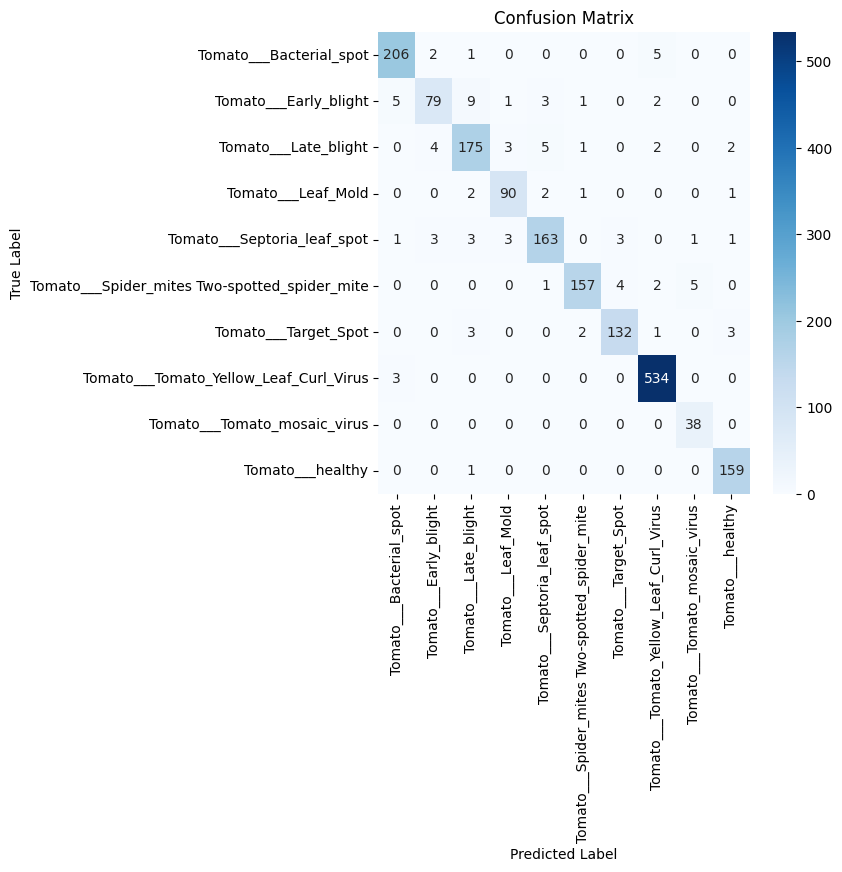

In [ ]:
plot_confusion_matrix(model, test_data)

Plotting the Acuraccy and Loss of models

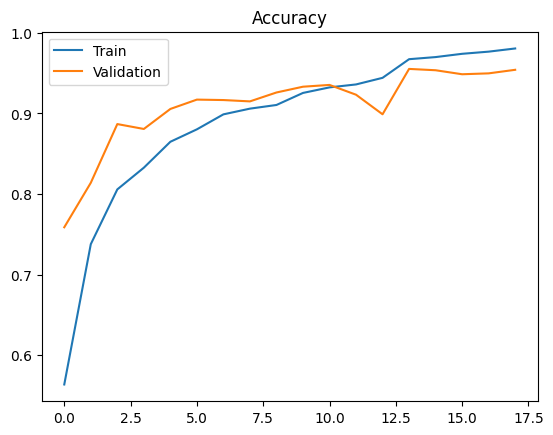

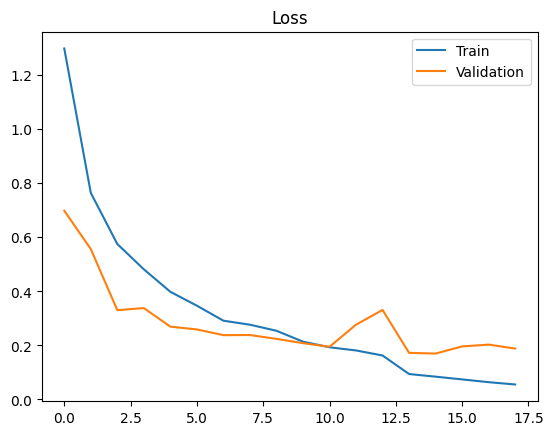

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Loss")
plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_data)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9547 - loss: 0.1693
Validation Loss: 0.1693039834499359
Validation Accuracy: 0.9547461271286011


In [ ]:
import numpy as np

predictions = model.predict(val_data)

# Convert probabilities to class index
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
[7 1 7 9 5 8 0 0 7 4]


In [ ]:
true_classes = val_data.classes
print(true_classes[:10])

[0 0 0 0 0 0 0 0 0 0]


Predicting the Disease On the image:

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/c30fafa6-719d-419c-a5fe-a45f3bb4ad5d___YLCV_GCREC 2798_final_masked.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/c30fafa6-719d-419c-a5fe-a45f3bb4ad5d___YLCV_GCREC 2798_final_masked.jpg'

In [ ]:
prediction = model.predict(img_array)

predicted_class_index = np.argmax(prediction)
confidence = np.max(prediction) * 100

NameError: name 'img_array' is not defined

In [ ]:
class_labels = list(train_data.class_indices.keys())
predicted_label = class_labels[predicted_class_index]

print("Predicted Disease:", predicted_label)
print(f"Confidence: {confidence:.2f}%")

NameError: name 'predicted_class_index' is not defined